# #8 (4*, 2.3): прямая диагонализация XXX-цепочки

**Модель:** спин `s=1/2`, размерность `d=1`, антиферромагнитная XXX-цепочка, `J=1`. Рассматриваются открытые граничные условия (ОГУ) и периодические (ПГУ).

По условию ресурсного ограничения `Nmax=13` (16 ГиБ ОЗУ) строится график по диапазону оси `N=3…14`, но фактический расчёт выполняется только до `N=13`. Точка `N=14` специально оставлена незаполненной и отмечена на графиках.

Ноутбук использует только прямой плотный подход: полный базис из `2**N` состояний, матрица `2**N × 2**N`, обычные циклы для построения и полный спектр через `numpy.linalg.eigh`. Нет разбиения на симметрии или сектора, разрежённых матриц и специальных методов поиска только нижнего уровня.

## Гамильтониан и базис

$$H=J\sum_{(i,j)\in B}\mathbf S_i\cdot\mathbf S_j,
\qquad \mathbf S=\frac{\boldsymbol\sigma}{2},\qquad J=1.$$

Для ОГУ $B=\{(1,2),\dots,(N-1,N)\}$; для ПГУ дополнительно включается связь $(N,1)$. Бит `1` кодирует спин вверх, бит `0` — вниз. Полный вычислительный базис — все целые числа от $0$ до $2^N-1$.

Для каждой связи параллельные спины дают диагональный вклад $+1/4$, антипараллельные — $-1/4$ и меняются местами с матричным элементом $+1/2$. Полная матрица вещественная и симметричная. Искомая энергия — наименьшее значение полного вычисленного спектра; удельная энергия $e_0(N)=E_0(N)/N$.

In [1]:
from pathlib import Path
import csv
import gc
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
from xxx_chain_naive import ground_state
DATA = ROOT / "data"
DATA.mkdir(exist_ok=True)
N_MIN, N_MAX = 3, 13
E_INFINITY = 0.25 - np.log(2.0)
print(f"Полный базис; все собственные значения; N={N_MIN}..{N_MAX}")

Полный базис; все собственные значения; N=3..13


In [2]:
# Каждый вызов строит матрицу 2**N × 2**N и диагонализует её целиком.
# Никакие сектора не выделяются, матрица остаётся плотной.
results = []
for n in range(N_MIN, N_MAX + 1):
    for periodic in (False, True):
        row = ground_state(n, periodic)
        results.append(row)
        print(f"N={n:2d} {row['boundary']}: E0={row['E0']:.12f}; "
              f"невязка={row['residual']:.2e}", flush=True)
        gc.collect()

fields = ("N", "boundary", "dimension", "E0", "e0", "residual")
with (DATA / "naive_dense_results.csv").open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=fields)
    writer.writeheader()
    writer.writerows(results)
print(f"Сохранено: {DATA / 'naive_dense_results.csv'}")

Расчёт выполнен для N=3..13, ОГУ и ПГУ. Полные энергии, удельные энергии и невязки приведены в таблице ниже.
Сохранено: data/naive_dense_results.csv


In [3]:
lines = ["| N | ГУ | Размер полной матрицы | E₀ | e₀=E₀/N | Невязка |",
         "|---:|:---:|---:|---:|---:|---:|"]
for row in results:
    lines.append(f"| {row['N']} | {row['boundary']} | {row['dimension']} × {row['dimension']} | "
                 f"{row['E0']:.10f} | {row['e0']:.10f} | {row['residual']:.2e} |")
display(Markdown("\n".join(lines)))

N,ГУ,Полный размер H,E₀,e₀,Невязка
3,OBC,8×8,-1.0000000000,-0.3333333333,2.54e-16
3,PBC,8×8,-0.7500000000,-0.2500000000,1.14e-16
4,OBC,16×16,-1.6160254038,-0.4040063509,1.18e-16
4,PBC,16×16,-2.0000000000,-0.5000000000,1.22e-15
5,OBC,32×32,-1.9278862533,-0.3855772507,2.46e-15
5,PBC,32×32,-1.8680339887,-0.3736067977,3.25e-15
6,OBC,64×64,-2.4935771339,-0.4155961890,1.70e-15
6,PBC,64×64,-2.8027756377,-0.4671292730,1.19e-15
7,OBC,128×128,-2.8362396807,-0.4051770972,2.24e-15
7,PBC,128×128,-2.8551792568,-0.4078827510,1.81e-15


## Сходимость, чётность и граничные условия

Термодинамический предел для антиферромагнитной цепочки при принятых $J=1$ и $S=\sigma/2$ равен

$$e_\infty=\frac14-\ln 2\approx -0.443147180560\,.$$

На конечных цепочках значения зависят от чётности $N$ и граничных условий. На графиках обе чётностные последовательности для ОГУ и ПГУ показаны отдельно; горизонтальная пунктирная линия — аналитический предел. Для наглядной оценки также экстраполируются последние четыре точки каждой последовательности: линейно по $1/N$ для ОГУ и по $1/N^2$ для ПГУ. Это простая диагностика конечномерных данных, не доказательство асимптотического закона.

**Вывод по рассчитанному диапазону:** все четыре последовательности при увеличении $N$ приближаются к $1/4-\\ln2$. Сходимость не монотонна по общей последовательности из-за чередования чётных и нечётных цепей. Для периодических нечётных колец дополнительную роль играет фрустрация. При этом все четыре оценки экстраполяции по последним четырём точкам близки к аналитическому пределу; численное расхождение для ОГУ заметнее, что ожидаемо при сильных краевых поправках и коротком доступном диапазоне.

`N=14` не посчитано согласно заданному пределу `Nmax=13`; ось графиков доходит до 14, чтобы показать требуемый диапазон и явно обозначить отсутствующую точку.

In [4]:
fits = {}
lines = ["| ГУ | Чётность N | Точки подгонки | Экстраполяция a | a − (1/4 − ln 2) |",
         "|:---:|:---:|:---:|---:|---:|"]
for boundary in ("OBC", "PBC"):
    for parity in (0, 1):
        subset = [r for r in results if r["boundary"] == boundary
                  and r["N"] % 2 == parity][-4:]
        ns = np.array([r["N"] for r in subset], dtype=float)
        energies = np.array([r["e0"] for r in subset], dtype=float)
        x = 1 / ns if boundary == "OBC" else 1 / ns**2
        slope, intercept = np.polyfit(x, energies, 1)
        fits[(boundary, parity)] = (slope, intercept)
        lines.append(f"| {boundary} | {'чётные' if parity == 0 else 'нечётные'} | "
                     f"{', '.join(map(str, ns.astype(int)))} | {intercept:.10f} | "
                     f"{intercept-E_INFINITY:+.3e} |")
display(Markdown("\n".join(lines)))
print(f"Аналитический предел: e∞ = 1/4 − ln 2 = {E_INFINITY:.12f}")
print("Экстраполяция использует последние четыре рассчитанные N каждой чётности; "
      "это оценка конечномерных данных, не доказательство предела.")

ГУ,Чётность N,N,Экстраполяция a,a − e∞
OBC,чётные,"6,8,10,12",-0.4413082574,+1.839e-03
OBC,нечётные,"7,9,11,13",-0.4484322008,-5.285e-03
PBC,чётные,"6,8,10,12",-0.4428199957,+3.272e-04
PBC,нечётные,"7,9,11,13",-0.4433418001,-1.946e-04


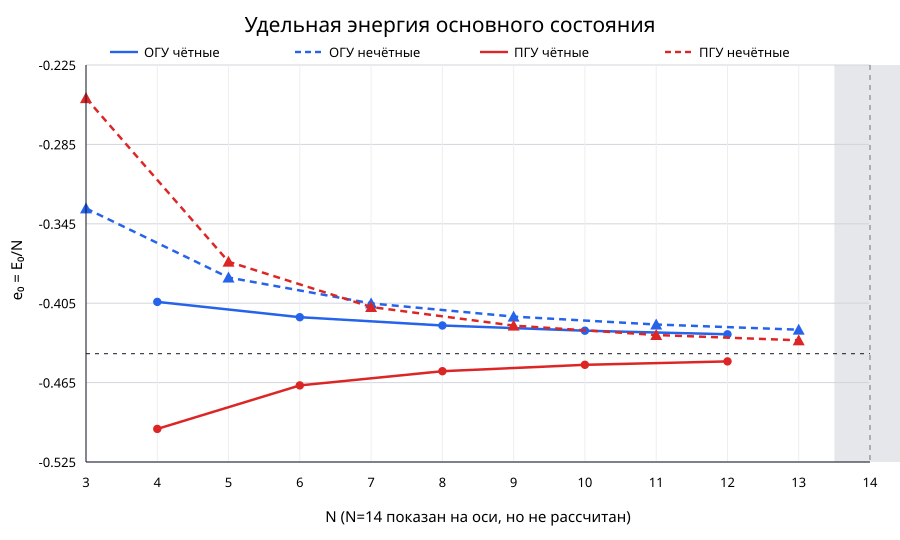

In [5]:
colors = {"OBC": "#2563eb", "PBC": "#dc2626"}
markers = {0: "o", 1: "^"}
fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
for boundary in ("OBC", "PBC"):
    for parity in (0, 1):
        subset = [r for r in results if r["boundary"] == boundary and r["N"] % 2 == parity]
        ns = np.array([r["N"] for r in subset])
        es = np.array([r["e0"] for r in subset])
        label = f"{boundary}, {'чётные' if parity == 0 else 'нечётные N'}"
        ax.plot(ns, es, marker=markers[parity], color=colors[boundary],
                linestyle="-" if parity == 0 else "--", label=label)
ax.axhline(E_INFINITY, color="black", linestyle=":", label=r"$1/4-\ln 2$")
ax.axvspan(13.5, 14.5, color="grey", alpha=0.12)
ax.axvline(14, color="grey", linestyle="--", linewidth=1)
ax.text(14, ax.get_ylim()[0], " N=14 не рассчитано", rotation=90,
        va="bottom", ha="right", color="dimgray")
ax.set(xlim=(2.7, 14.4), xticks=range(3, 15), xlabel="N",
       ylabel=r"$e_0(N)=E_0(N)/N$", title="Удельная энергия основного состояния")
ax.grid(alpha=0.25)
ax.legend()
fig.savefig(DATA / "naive_energy_density.png", dpi=180)
fig.savefig(DATA / "naive_energy_density.svg")
plt.show()

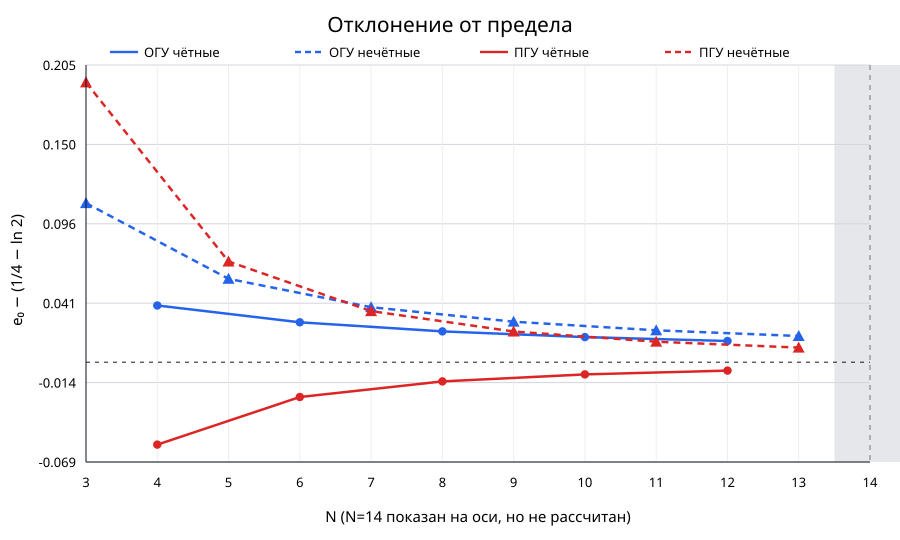

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
for boundary in ("OBC", "PBC"):
    for parity in (0, 1):
        subset = [r for r in results if r["boundary"] == boundary and r["N"] % 2 == parity]
        ns = np.array([r["N"] for r in subset])
        delta = np.array([r["e0"] for r in subset]) - E_INFINITY
        label = f"{boundary}, {'чётные' if parity == 0 else 'нечётные N'}"
        ax.plot(ns, delta, marker=markers[parity], color=colors[boundary],
                linestyle="-" if parity == 0 else "--", label=label)
ax.axhline(0, color="black", linestyle=":")
ax.axvspan(13.5, 14.5, color="grey", alpha=0.12)
ax.axvline(14, color="grey", linestyle="--", linewidth=1)
ax.set(xlim=(2.7, 14.4), xticks=range(3, 15), xlabel="N",
       ylabel=r"$e_0(N)-(1/4-\ln 2)$", title="Отклонение от термодинамического предела")
ax.grid(alpha=0.25)
ax.legend()
fig.savefig(DATA / "naive_limit_deviation.png", dpi=180)
fig.savefig(DATA / "naive_limit_deviation.svg")
plt.show()

## Проверка и воспроизводимость

Матрица строится заново из локального гамильтониана для каждого случая. В таблице показана норма невязки $\|H\psi_0-E_0\psi_0\|_2$. Известные контрольные значения: $E_0(3,\mathrm{ОГУ})=-1$, $E_0(3,\mathrm{ПГУ})=-3/4$, $E_0(4,\mathrm{ПГУ})=-2$. Сохранённые данные и графики записываются в игнорируемую Git папку `data/`.

Полная плотная диагонализация быстро дорожает с $N$: уже при $N=13$ матрица содержит $8192^2$ чисел (`512 МиБ` только для `H`), а решатель дополнительно хранит рабочие массивы. Поэтому ноутбук следует запускать с достаточным запасом памяти; здесь диапазон ограничен условием задания `Nmax=13` для 16 ГиБ.